# Bayes sampling by library
+ Here, we show two libraries to sample from posterior distribution: tensorflow_probability and pystan

# Tensorflow_probability case

In [1]:
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp

In [3]:
tfd = tfp.distributions
tfb = tfp.bijectors
mcmc = tfp.mcmc

## data setting

In [6]:
true_w = [0.5, -1.2, 0.3]

In [8]:
data_seed = 20251008
np.random.seed(data_seed)
N = 100
train_x = np.linspace(-1, 1, N).astype(np.float32)
train_y = true_w[0] + true_w[1] * train_x + np.random.normal(0, true_w[2], size=N).astype(np.float32)

train_x = tf.constant(train_x)
train_y = tf.constant(train_y)

In [10]:
hyperparams = [5., 5., 1.]
def target_log_prob_fn(w0, w1, unconstrained_sigma):
    scale0, scale1, scale_sig = hyperparams
    sigma = tf.nn.softplus(unconstrained_sigma)

    lp = tfd.Normal(0., scale0).log_prob(w0)
    lp += tfd.Normal(0, scale1).log_prob(w1)
    lp += tfd.Normal(0, scale_sig).log_prob(unconstrained_sigma)

    y_pred = w0[..., tf.newaxis] + w1[..., tf.newaxis] * train_x
    lp += tf.reduce_sum(
        tfd.Normal(y_pred, sigma[..., tf.newaxis]).log_prob(train_y),
        axis=-1,
    )
    return lp

## MCMC setting

In [13]:
num_chains = 4

In [15]:
tf.random.set_seed(20251009)

In [17]:
initial_state = [
    # tf.zeros([num_chains], dtype=tf.float32),
    # tf.zeros([num_chains], dtype=tf.float32),
    # tf.zeros([num_chains], dtype=tf.float32),
    tf.random.normal([num_chains], 0., 0.5),
    tf.random.normal([num_chains], 0., 0.5),
    tf.random.normal([num_chains], 0., 0.5),
]

In [19]:
num_results = 2000
num_burin_steps = 1000

In [21]:
hmc_kernel = mcmc.HamiltonianMonteCarlo(
    target_log_prob_fn=target_log_prob_fn,
    step_size=0.05,
    num_leapfrog_steps=3,
)

adapt_kernel = mcmc.SimpleStepSizeAdaptation(
    inner_kernel=hmc_kernel,
    num_adaptation_steps=int(num_burin_steps * 0.8),
    target_accept_prob=0.75,
)

In [23]:
@tf.function
def run_chain():
    samples, kernel_results = mcmc.sample_chain(
        num_results=num_results,
        num_burnin_steps=num_burin_steps,
        current_state=initial_state,
        kernel=adapt_kernel,
        trace_fn=lambda current_state, kr: kr
    )
    return samples, kernel_results

In [25]:
samples, kr = run_chain()

In [26]:
w0_samples, w1_samples, unconstrained_sigma_samples = samples
sigma_samples = tf.nn.softplus(unconstrained_sigma_samples)

In [27]:
rhat_w0 = tfp.mcmc.diagnostic.potential_scale_reduction(w0_samples)
rhat_w1 = tfp.mcmc.diagnostic.potential_scale_reduction(w1_samples)
rhat_sigma = tfp.mcmc.diagnostic.potential_scale_reduction(sigma_samples)

In [28]:
ess_w0 = tfp.mcmc.diagnostic.effective_sample_size(w0_samples)
ess_w1 = tfp.mcmc.diagnostic.effective_sample_size(w1_samples)
ess_sigma = tfp.mcmc.diagnostic.effective_sample_size(sigma_samples)

In [29]:
print("R-hat w0:", rhat_w0.numpy())
print("R-hat w1:", rhat_w1.numpy())
print("R-hat sigma:", rhat_sigma.numpy())
print("ESS w0:", ess_w0.numpy())
print("ESS w1:", ess_w1.numpy())
print("ESS sigma:", ess_sigma.numpy())


R-hat w0: 1.0014509
R-hat w1: 1.0000645
R-hat sigma: 0.9998464
ESS w0: [744.945   668.7549  608.0762  562.52734]
ESS w1: [2000. 2000. 2000. 2000.]
ESS sigma: [1574.1288 1482.9563 1519.292  1626.4955]


print("Posterior mean w0:", tf.reduce_mean(w0_samples).numpy())
print("Posterior mean w1:", tf.reduce_mean(w1_samples).numpy())
print("Posterior mean sigma:", tf.reduce_mean(sigma_samples).numpy())

## SGLDをする場合

In [182]:
def compute_rhat(samples):
    chain_means = tf.reduce_mean(samples, axis=1)
    chain_vars = tf.math.reduce_variance(samples, axis=1)

    overall_mean = tf.reduce_mean(chain_means, axis=0)

    num_chains = tf.cast(tf.shape(samples)[0], tf.float32)
    num_samples = tf.cast(tf.shape(samples)[1], tf.float32)

    var_between_chain = num_samples * tf.reduce_mean(tf.square(chain_means - overall_mean), axis=0)
    var_in_chain = tf.reduce_mean(chain_vars, axis=0)

    var_hat = (num_samples - 1) / num_samples * var_in_chain + var_between_chain / num_samples
    R_hat = tf.sqrt(var_hat / var_in_chain)

    return R_hat

In [134]:
lr = 1e-4
num_steps = 5000
samples = []

In [136]:
ln_seed = 20251009
num_chains = 4
tf.random.set_seed(ln_seed)

w0 = tf.Variable(tf.random.normal([num_chains]))
w1 = tf.Variable(tf.random.normal([num_chains]))
log_sigma = tf.Variable(tf.random.normal([num_chains]))

In [138]:
hyperparams = [5., 5., 1.]

def loss_fn():
    sigma = tf.nn.softplus(log_sigma)
    y_pred = w0[..., tf.newaxis] + w1[..., tf.newaxis] * train_x
    log_likelihood = tf.reduce_sum(
        tfd.Normal(y_pred, sigma[..., tf.newaxis]).log_prob(train_y),
        axis=-1,
    )
    log_prior = (
        tfd.Normal(0., hyperparams[0]).log_prob(w0) +
        tfd.Normal(0., hyperparams[1]).log_prob(w1) +
        tfd.Normal(0., hyperparams[2]).log_prob(log_sigma)
    )

    return -(log_likelihood + log_prior)

In [152]:
@tf.function
def run_sgld(num_steps):
    num_samples = num_steps // 10
    samples_ta = tf.TensorArray(
        dtype=tf.float32, 
        size=num_samples,
        element_shape=(num_chains, 3)
    )
    
    sample_idx = 0
    
    for step in tf.range(num_steps):
        with tf.GradientTape() as tape:
            # loss = loss_fn(w0, w1, log_sigma)
            loss = loss_fn()
        grads = tape.gradient(loss, [w0, w1, log_sigma])
    
        for var, grad in zip([w0, w1, log_sigma], grads):
            noise = tf.random.normal(shape=var.shape, stddev=tf.sqrt(lr))
            var.assign_sub(0.5 * lr * grad - noise)


        if step % 10 == 0:
            sample = tf.stack([w0, w1, tf.nn.softplus(log_sigma)])
            # tf.print(f"step = {step}, sample = {sample}")
            samples_ta = samples_ta.write(sample_idx, tf.transpose(sample))
            sample_idx += 1

    return tf.transpose(samples_ta.stack(), [1, 0, 2])

In [154]:
samples = run_sgld(5000)

In [150]:
samples.shape

TensorShape([4, 500, 3])

In [160]:
tf.reduce_mean(samples, axis=1)

<tf.Tensor: shape=(4, 3), dtype=float32, numpy=
array([[ 0.4604293 , -1.2578907 ,  0.30945957],
       [ 0.46183002, -1.2583177 ,  0.3045992 ],
       [ 0.46447092, -1.270078  ,  0.31811878],
       [ 0.46171728, -1.2594953 ,  0.29928824]], dtype=float32)>

In [184]:
compute_rhat(samples)

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([1.0000159, 1.0038774, 1.0391874], dtype=float32)>

In [170]:
import matplotlib.pyplot as plt

In [172]:
np_samples = samples.numpy()

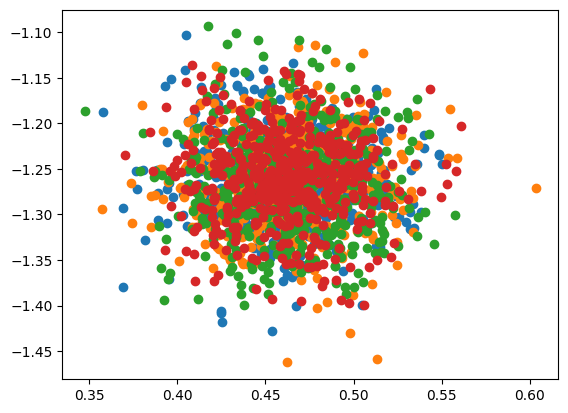

In [209]:
for sample_chain in np_samples:
    plt.scatter(sample_chain[:,0], sample_chain[:,1])

## 特異モデルの場合
+ f(x;w) = a tanh(bx)でチェック

In [325]:
true_w = [0.0, 0.0]

In [327]:
data_seed = 20251008
np.random.seed(data_seed)
N = 100
train_x = np.linspace(-1, 1, N).astype(np.float32)
train_y = true_w[0] * np.tanh(true_w[1] * train_x) + np.random.normal(0, 1, size=N).astype(np.float32)

train_x = tf.constant(train_x)
train_y = tf.constant(train_y)

In [329]:
ln_seed = 20251009
num_chains = 4
tf.random.set_seed(ln_seed)

w0 = tf.Variable(tf.random.normal([num_chains]))
w1 = tf.Variable(tf.random.normal([num_chains]))

In [331]:
hyperparams = [5., 5.]

def loss_fn():
    y_pred = w0[..., tf.newaxis] * tf.tanh(w1[..., tf.newaxis] * train_x)
    log_likelihood = tf.reduce_sum(
        tfd.Normal(y_pred, 1.).log_prob(train_y),
        axis=-1,
    )
    log_prior = (
        tfd.Normal(0., hyperparams[0]).log_prob(w0) +
        tfd.Normal(0., hyperparams[1]).log_prob(w1)
    )

    return -(log_likelihood + log_prior)

In [333]:
@tf.function
def run_sgld(num_steps):
    num_samples = num_steps // 10
    samples_ta = tf.TensorArray(
        dtype=tf.float32, 
        size=num_samples,
        element_shape=(num_chains, 2)
    )
    
    sample_idx = 0
    
    for step in tf.range(num_steps):
        with tf.GradientTape() as tape:
            # loss = loss_fn(w0, w1, log_sigma)
            loss = loss_fn()
        grads = tape.gradient(loss, [w0, w1])
    
        for var, grad in zip([w0, w1], grads):
            noise = tf.random.normal(shape=var.shape, stddev=tf.sqrt(lr))
            var.assign_sub(0.5 * lr * grad - noise)


        if step % 50 == 0:
            sample = tf.stack([w0, w1])
            # tf.print(f"step = {step}, sample = {sample}")
            samples_ta = samples_ta.write(sample_idx, tf.transpose(sample))
            sample_idx += 1

    return tf.transpose(samples_ta.stack(), [1, 0, 2])

In [335]:
lr = 1e-4
num_steps = 20000
samples = []

In [337]:
samples = run_sgld(num_steps)

In [339]:
np_samples = samples.numpy()

In [341]:
np_samples.shape

(4, 2000, 2)

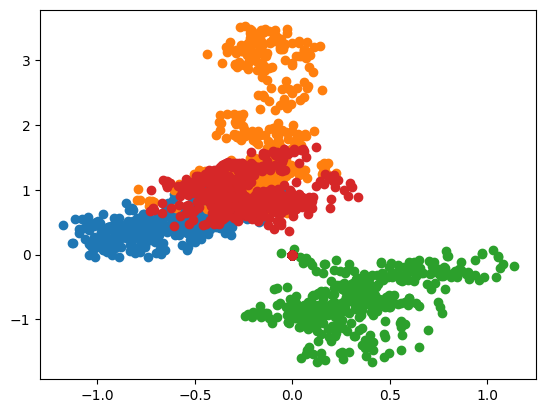

In [343]:
for sample_chain in np_samples:
    plt.scatter(sample_chain[:500,0], sample_chain[:500,1])

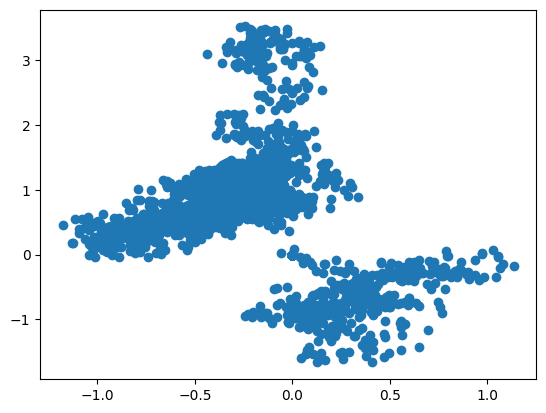

In [344]:
plt.scatter(np_samples[:,:500,0].flatten(), np_samples[:,:500,1].flatten())